## Load the cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned data we saved in the previous notebook
df = pd.read_csv('../data/cleaned_reviews.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3995, 7)


,review_text,rating,date,verified,country,clean_text,sentiment
0,✅Trip Verified| I'm not entirely sure as to wh...,8,2026-05-02,True,T Bayne(United Kingdom)2nd May 2026,trip verified im not entirely sure as to what ...,positive
1,✅Trip Verified| Our first time in the new bu...,8,2026-04-21,True,Kevin Tunnicliffe(United Kingdom)21st April 2026,trip verified our first time in the new busine...,positive
2,✅Trip Verified| Highly commendable again on ...,10,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026,trip verified highly commendable again on all ...,positive
3,✅Trip Verified| Highly commendable on all fr...,10,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026,trip verified highly commendable on all fronts...,positive
4,Not Verified| Although the staff on board t...,2,2026-04-06,False,Sarah Harrison(United Kingdom)6th April 2026,not verified although the staff on board the f...,negative


# Sentiment breakdown

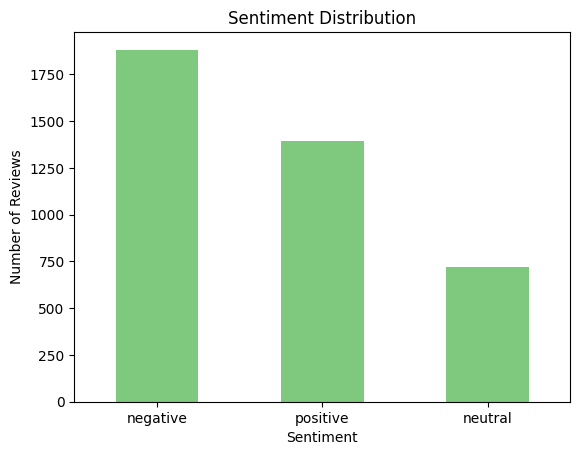

sentiment
negative    1882
positive    1393
neutral      720
Name: count, dtype: int64


In [ ]:
# Count number of reviews fall in each sentiment group
sentiment_counts = df['sentiment'].value_counts()

# Plot it
sentiment_counts.plot(kind='bar', colormap= 'Accent')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

print(sentiment_counts)

## Verified vs unverified average rating

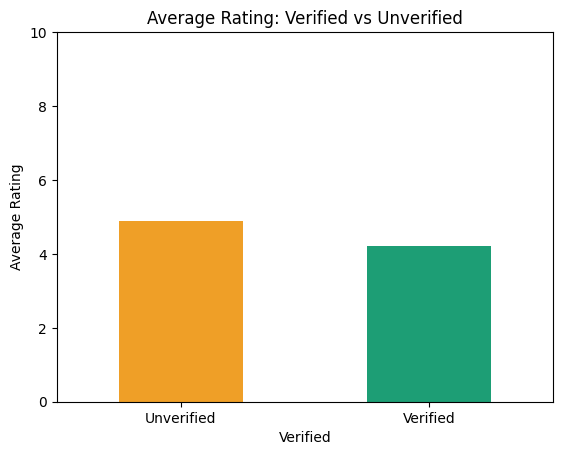

verified
False    4.891413
True     4.214592
Name: rating, dtype: float64


In [15]:
# Compare average rating between verified and unverified reviewers
verified_avg = df.groupby('verified')['rating'].mean()

verified_avg.plot(kind='bar', color=['#EF9F27', '#1D9E75'])
plt.title('Average Rating: Verified vs Unverified')
plt.xlabel('Verified')
plt.ylabel('Average Rating')
plt.xticks([0, 1], ['Unverified', 'Verified'], rotation=0)
plt.ylim(0, 10)
plt.show()

print(verified_avg)

## Word cloud of negative reviews

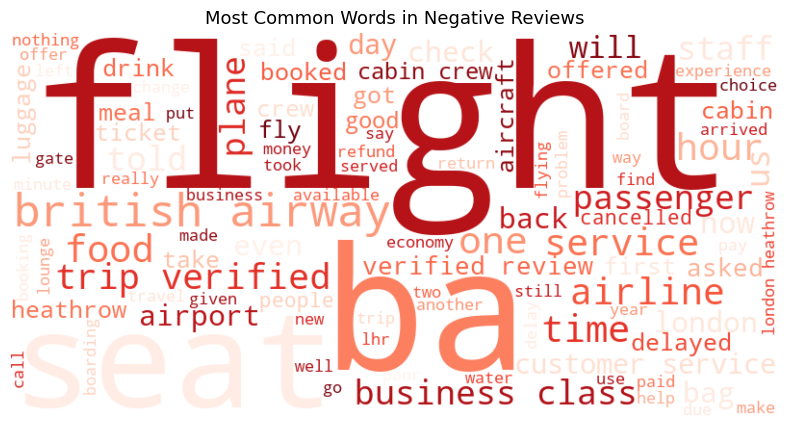

In [16]:
from wordcloud import WordCloud

# Filter only negative reviews
negative_reviews = df[df['sentiment'] == 'negative']['clean_text']

# Join all negative review text into one big string
all_negative_text = ' '.join(negative_reviews)

# Generate the word cloud
# The bigger the word, the more times it appears in negative reviews
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(all_negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews', fontsize=13)
plt.show()

## Word cloud of positive reviews

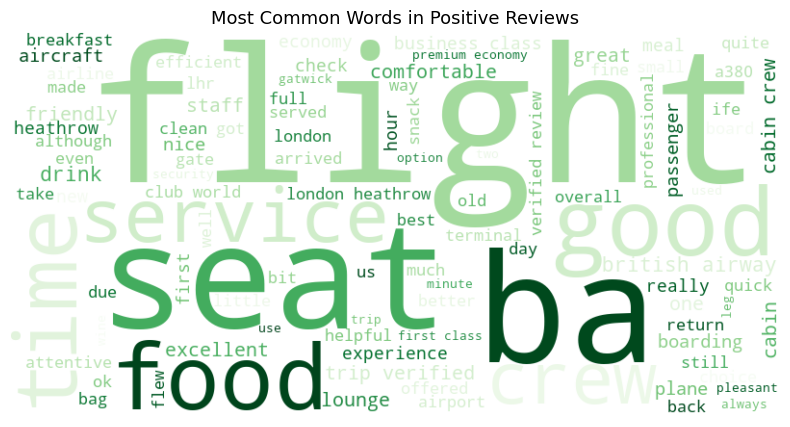

In [17]:
# Filter only positive reviews
positive_reviews = df[df['sentiment'] == 'positive']['clean_text']

all_positive_text = ' '.join(positive_reviews)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(all_positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews', fontsize=13)
plt.show()

##  Top 10 most common complaint words

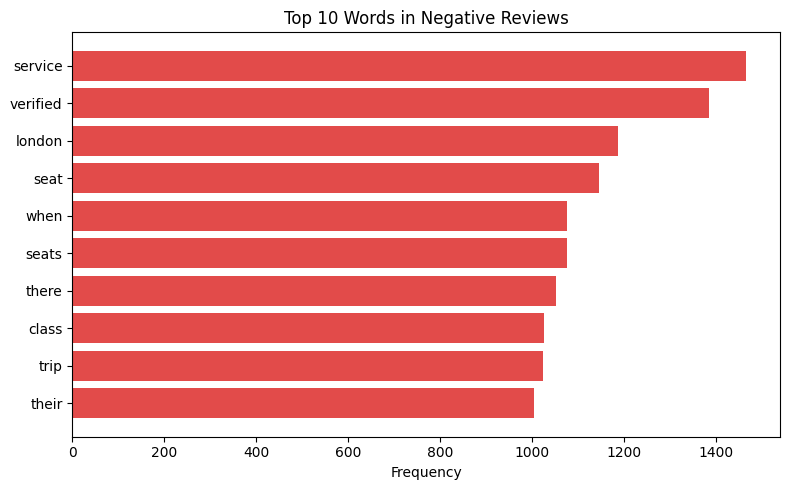

In [22]:
from collections import Counter

# Split all negative reviews into individual words
negative_words = all_negative_text.split()

# Count how many times each word appears
word_counts = Counter(negative_words)


# Filter out stopwords and keep the top 10 remaining words
filtered_counts = {
    word: count
    for word, count in word_counts.items()
    if word not in stopwords and len(word) > 3
}
top_10 = dict(Counter(filtered_counts).most_common(10))

# Plot as a horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(list(top_10.keys()), list(top_10.values()), color='#E24B4A')
plt.title('Top 10 Words in Negative Reviews')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()  # most common word at the top
plt.tight_layout()
plt.show()